In [1]:
import pandas as pd

### Loading the dataset

In [2]:
medical_df = pd.read_csv('insurance.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


The dataset consists of 1338 rows and 7 columns

In [3]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Exploratory Analysis and Visualization

In [5]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [7]:
medical_df['age'].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

Youngest person is 18 with the oldest being 64  
Age difference is 46

#### Age Distribution

In [8]:
fig = px.histogram(medical_df, x='age', nbins=47, marginal='box', title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

Most of the data is based on 18 and 19 year olds

#### BMI distribution

In [9]:
fig = px.histogram(medical_df, x='bmi', marginal='box', color_discrete_sequence=['red'], title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()


The highest frequency of bmi ranges from 27 to 33

#### Annual medical charges by smoker

In [123]:
fig = px.histogram(medical_df, x='charges', marginal='box', color='smoker', color_discrete_sequence=['red','green'], title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

Non-smokers face fewer medical charges compared to smokers.  
For non-smokers, the minimum charge is 1121 while maximum is 36k  
For smokers, the minimum charge is 12k while maximum is 63k

#### Distribution of medical charges with sex

In [ ]:
fig = px.histogram(medical_df, x='charges', marginal='box', color='sex', title='Distribution of medical charges by sex')
fig.update_layout(bargap=0.1)
fig.show()

For both the genders, the data is right skewed with long tails(many outliers).

#### Distribution of medical charges by region

In [ ]:
fig = px.histogram(medical_df, x='charges', marginal='box', color='region')
fig.update_layout(boxgap=0.1)
fig.show()

Most of the charges recorded in the regions is below 15k leading to a right skewed graph.

#### Distribution of the smoker column

In [ ]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

Over 1000 non-smoker data and 274 on smokers

In [14]:
px.histogram(medical_df, x='smoker', color='sex', title='Smoker')

Most smokers are male compared to female

#### Region distribution

In [ ]:
px.histogram(medical_df, x='region', title='Region Distribution')

Southeast has the most amount of records

#### Children Distribution

In [ ]:
px.histogram(medical_df, x='children', title='Children Distribution', color='smoker')

#### Relationship between BMI and charges

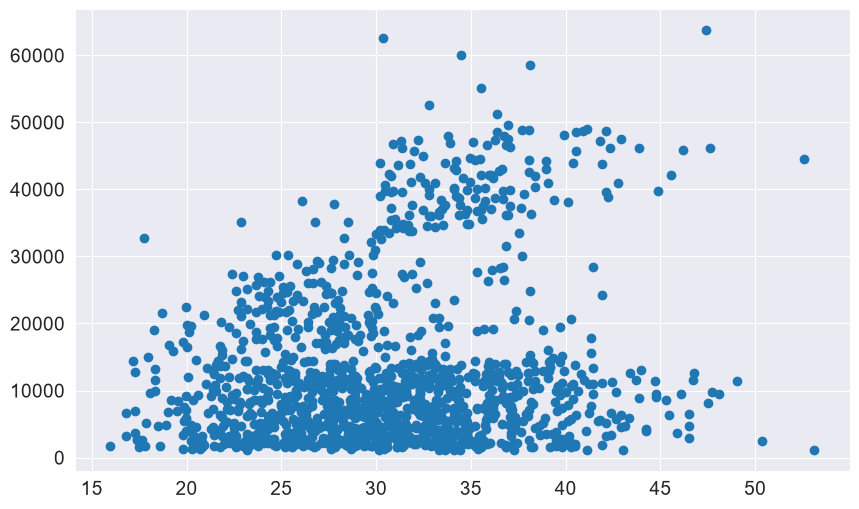

In [126]:
plt.scatter(data=medical_df, x='bmi', y='charges')

In [125]:
fig = px.scatter(medical_df, x='bmi', y='charges', color='smoker', hover_data=['sex'], opacity=0.8, title='BMI vs Charges')
fig.update_traces(marker_size=5)
fig.show()

When both the smokers and non-smokers are aggregated, the relationship between bmi and charges is not clear. -> Possible simpson paradox 
 
For non-smokers: There seems to be no relationship between bmi and charges  
For smokers: There is a positive relationship between bmi and charges

#### Relationship between charges and sex

In [ ]:
fig = px.violin(medical_df, x='sex', y='charges', color='smoker', title='Charges vs. sex')
fig.show()

Most of the non-smokers are charged less compared to smokers across the genders.  
For smokers: Most female pay less compared to male

#### Correlation

In [24]:
medical_df['charges'].corr(medical_df['age'])

np.float64(0.2990081933306478)

In [25]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362887)

In [26]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790487)

Encode smoker values to calculate the correlation with charges

In [27]:
smoker_values = {'no': 0, 'yes': 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984778)

In [28]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


From the dataframe, the variables have a weak positive correlation with charges with age holding the highest of 0.3.

Text(0.5, 1.0, 'Correlation Matrix')

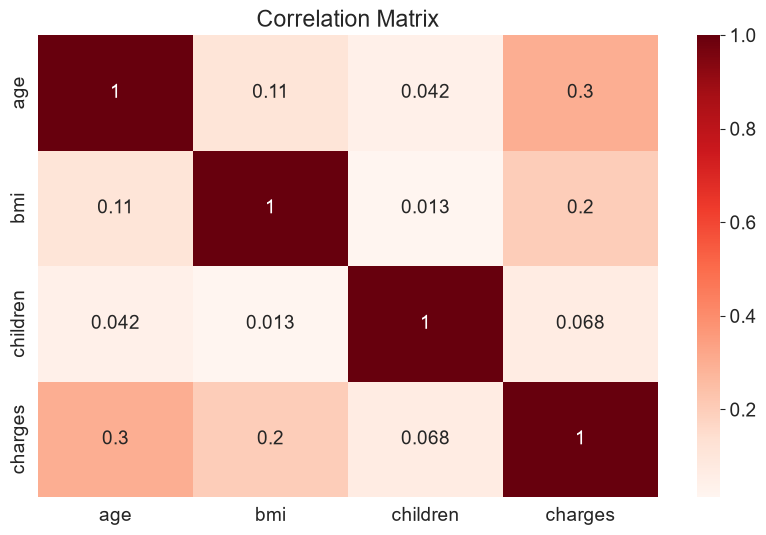

In [29]:
sns.heatmap(medical_df.corr(numeric_only=True), cmap='Reds', annot=True)
plt.title('Correlation Matrix')

### Estimating charges using age of non-smokers(Linear Regression)

In [30]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

<Axes: xlabel='age', ylabel='charges'>

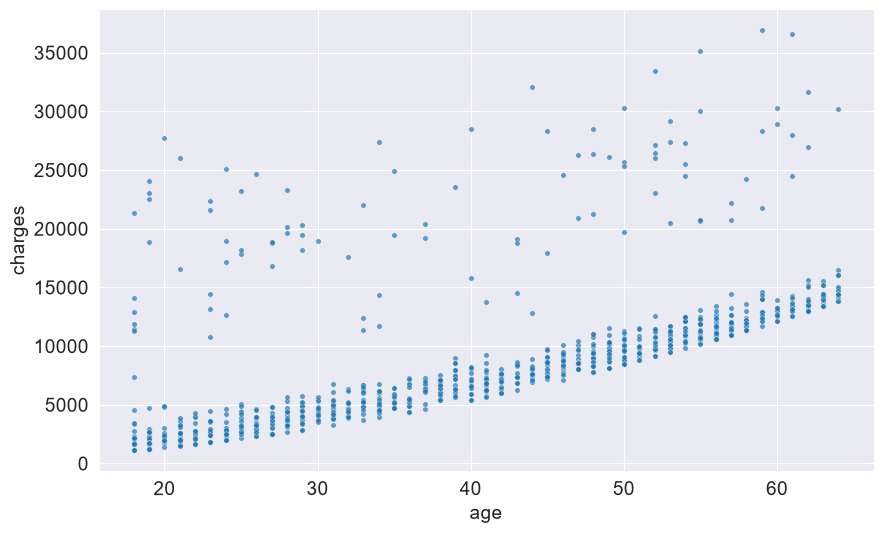

In [31]:
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15)

#### Model Training

Create function that works like the regression equation:  
It takes the age, weight/slope and intercept/bias then returns the estimate/prediction.

In [32]:
def estimate_charges(age, w, b):
  return w * age + b

In [33]:
w = 50
b = 100

estimate_charges(30, w, b)

1600

In [34]:
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages, w, b)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

The try_parameters function takes the weight and intercept then applies it to estimate_charges(), regression equation function.  
It calculates the estimate for all non-smokers and plots a scatter plot fitted with a regression line.  

This function enables you to see the effect of the weight and intercept in calculating the estimate.

In [35]:
def try_parameters(w, b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges

  estimated_charges = estimate_charges(ages, w, b)

  plt.plot(ages, estimated_charges, 'r', alpha=0.9)
  plt.scatter(ages, target, s=8, alpha=0.8)
  plt.xlabel('Age')
  plt.ylabel('Charges')
  plt.legend(['Estimate', 'Actual'])

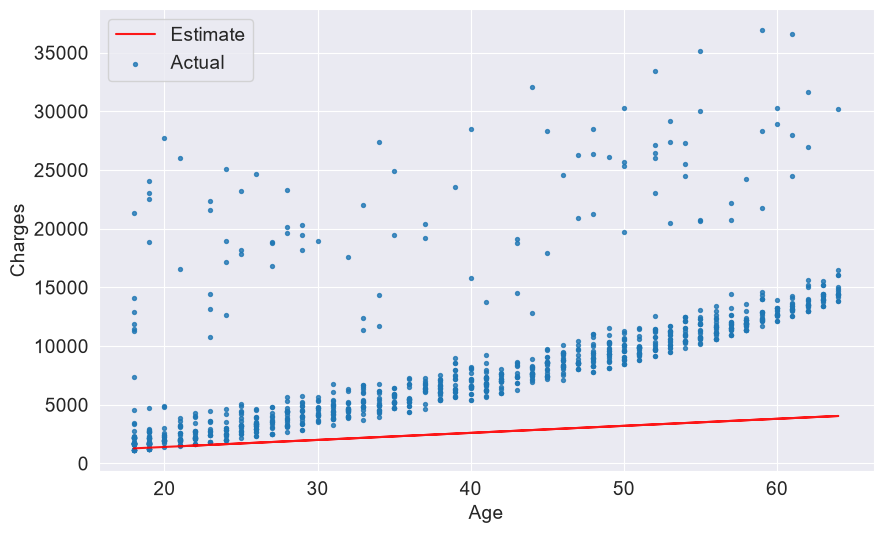

In [36]:
try_parameters(60, 200)

Changing the weight and intercept clearly has an impact to the regression line as seen from the previous plot and following plot

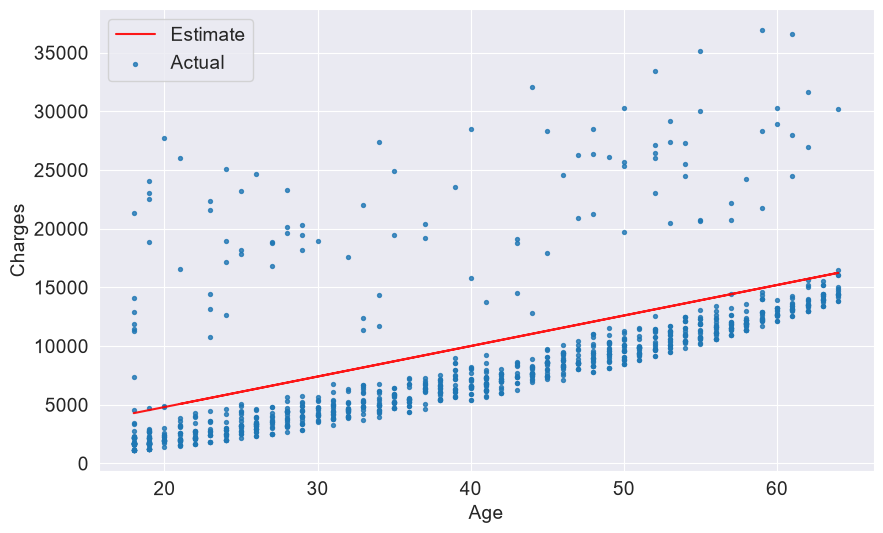

In [37]:
try_parameters(260, -400)

In [38]:
targets = non_smoker_df.charges
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [39]:
predictions = estimated_charges
predictions

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

#### Model evaluation

In [40]:
import numpy as np

Create a function rmse() that calculates the root mean squared error of the model

In [ ]:
def rmse(targets, predictions):
  return np.sqrt(np.mean(np.square(targets-predictions)))

Declare variable w(weight) and b(intercept) and plot a regression plot.  
The line is not the best fit.

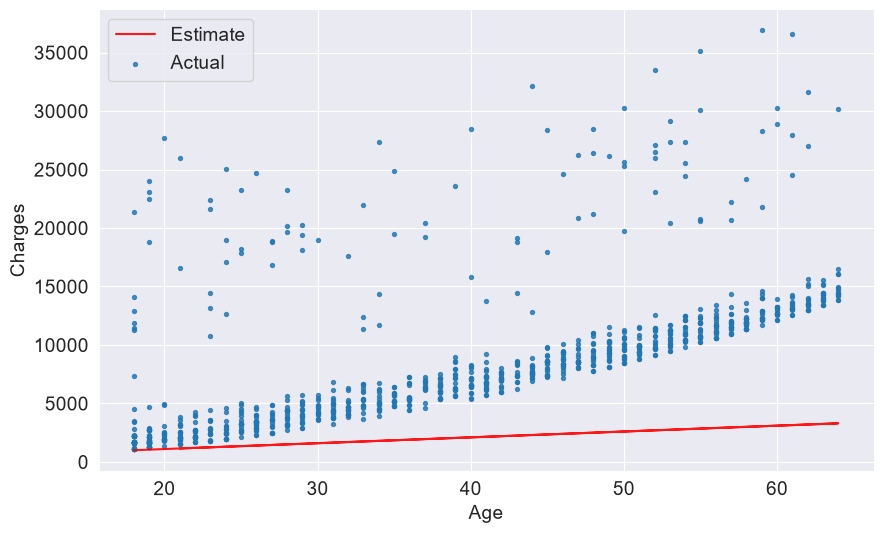

In [42]:
w = 50
b = 100
try_parameters(w, b)

Get the predictions using w and b

In [43]:
predicted = estimate_charges(non_smoker_df['age'], w, b)
predicted

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

Evaluate the model

In [44]:
rmse(targets, predicted)

np.float64(8461.949562575493)

The predictions have an error of approximately 8461 of the target

Update the try_parameters():
- Take weight and intercept
- Calculate charge estimate for non-smokers based on age as the only feature using estimate_charges()
- Plot scatter plot with a regression line
- Display the error of the model

In [ ]:
def try_parameters(w, b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges
  predictions = estimate_charges(ages, w, b)

  plt.plot(ages, predictions, 'r', alpha=0.9)
  plt.scatter(ages, target, s=8, alpha=0.8)
  plt.xlabel('Age')
  plt.ylabel('Charges')
  plt.legend(['Prediction', 'Actual'])

  loss = rmse(target, predictions)
  print('RMSE loss: ', loss)

RMSE loss:  8461.949562575493


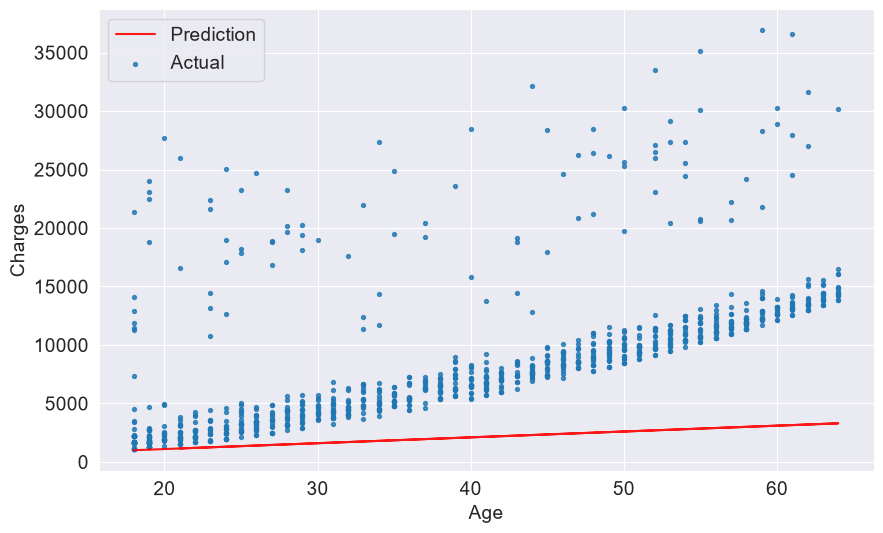

In [46]:
try_parameters(50, 100)

RMSE loss:  4956.973980899423


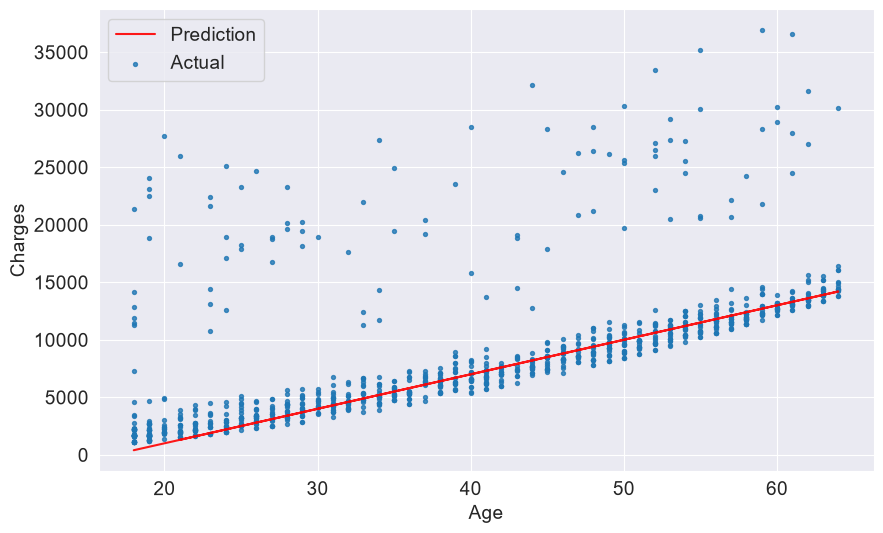

In [47]:
try_parameters(300, -5000)

### Linear Regression using Scikit Learn Ordinary Least Squares(OLS)

Get the estimate charges of non-smokers using their age

In [48]:
from sklearn.linear_model import LinearRegression

In [49]:
model = LinearRegression()

In [50]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges

In [51]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[267.25]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2091
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [52]:
model.predict(np.array([[23], [37], [61]]))

d:\Documents\Coding Prac\ML Projects\Predicting medical expenses using linear regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [53]:
# Charges predictions for non-smokers based on age
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [54]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [55]:
# slope
model.coef_

array([267.24891283])

In [56]:
# intercept
model.intercept_

np.float64(-2091.4205565650864)

RMSE loss:  4662.505766636395


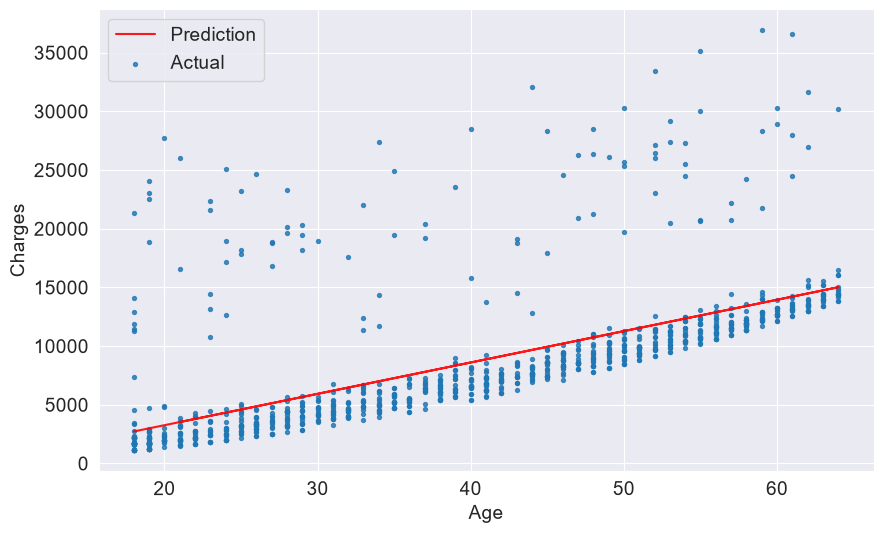

In [57]:
try_parameters(model.coef_, model.intercept_)

### Scikit-Learn's Linear regression using Stochaist Gradient Descent(SGD)

In [58]:
# Using gradient descent technique to train the model
from sklearn.linear_model import SGDRegressor

model_g = SGDRegressor()
model_g

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


In [59]:
model_g.fit(inputs, targets)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


In [60]:
predictions = model_g.predict(inputs)
predictions

array([3856.24125304, 5838.40373728, 6829.48497941, ..., 3856.24125304,
       3856.24125304, 4450.88999831], shape=(1064,))

In [61]:
rmse(targets, predictions)

np.float64(4774.753066239742)

In [62]:
model_g.coef_

array([198.21624842])

In [63]:
model_g.intercept_

array([288.34878139])

RMSE loss:  4774.753066239742


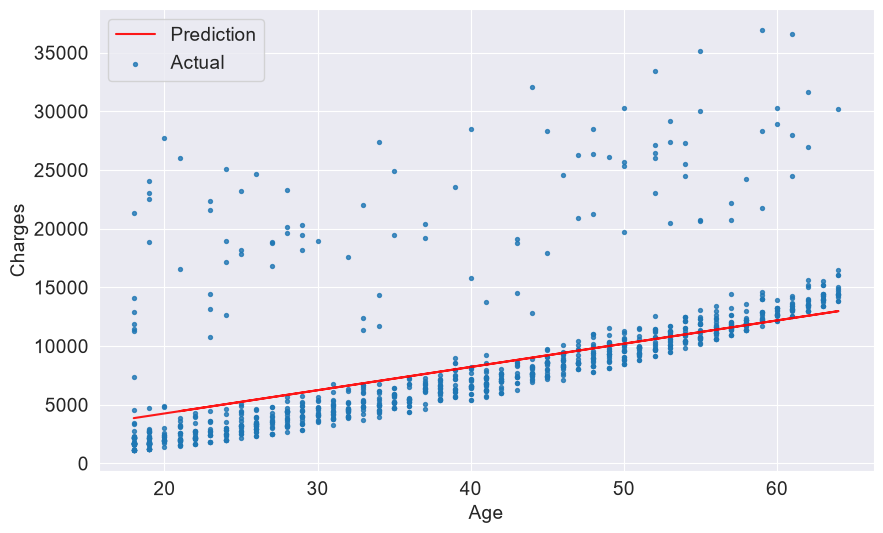

In [64]:
try_parameters(model_g.coef_, model_g.intercept_)

The model built using OLS was able to learn a better pattern than SGD model by getting an error of 4662 which is lower than SGD's 4774.

### Estimating medical charges for smokers based on age

In [65]:
smokers_df = medical_df[medical_df['smoker'] == 'yes']

<Axes: xlabel='age', ylabel='charges'>

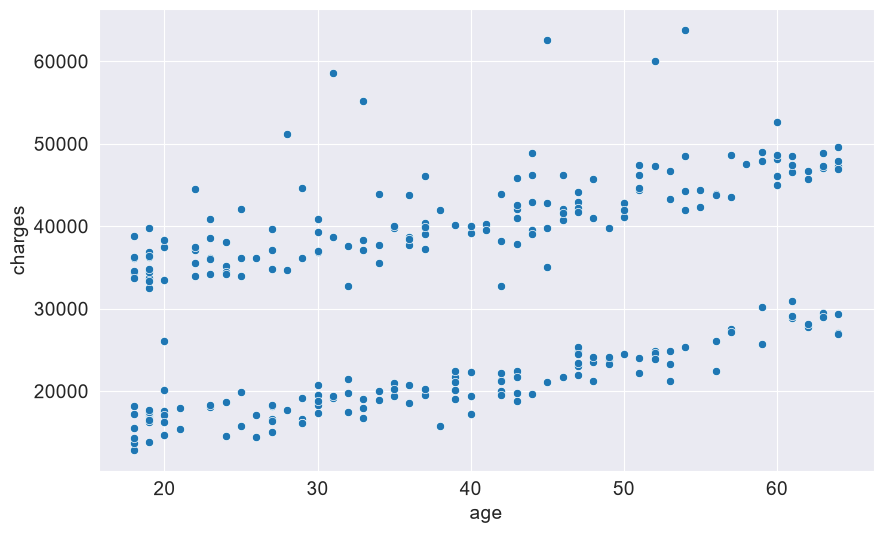

In [66]:
sns.scatterplot(smokers_df, x='age', y='charges')

#### Train the model

In [67]:
age_smoker_model = LinearRegression()

In [68]:
age_inputs = smokers_df[['age']]
charges_targets = smokers_df['charges']
age_smoker_model.fit(age_inputs, charges_targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[305.24]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.029e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [69]:
predictions = age_smoker_model.predict(age_inputs)
predictions

array([26093.642567  , 39218.85945773, 28535.54338388, 29451.25619021,
       30672.20659865, 29756.49379232, 27009.35537333, 28840.78098599,
       30977.44420076, 38608.38425351, 31282.68180287, 34945.53302819,
       31282.68180287, 37997.90904929, 25788.40496489, 36471.72103874,
       26398.88016911, 28840.78098599, 28535.54338388, 27009.35537333,
       31587.91940498, 34029.82022186, 37692.67144718, 38303.1466514 ,
       39829.33466195, 37387.43384507, 31893.15700709, 38913.62185562,
       26398.88016911, 39524.09705984, 29146.0185881 , 33724.58261975,
       26093.642567  , 30061.73139443, 30672.20659865, 29451.25619021,
       34335.05782397, 33114.10741553, 34945.53302819, 25788.40496489,
       29451.25619021, 33114.10741553, 25788.40496489, 39524.09705984,
       31282.68180287, 28535.54338388, 30977.44420076, 26093.642567  ,
       33114.10741553, 32503.63221131, 26093.642567  , 27314.59297544,
       39524.09705984, 25788.40496489, 39524.09705984, 36776.95864085,
      

In [70]:
charges_targets

0       16884.92400
11      27808.72510
14      39611.75770
19      36837.46700
23      37701.87680
           ...     
1313    36397.57600
1314    18765.87545
1321    28101.33305
1323    43896.37630
1337    29141.36030
Name: charges, Length: 274, dtype: float64

#### Model evaluation

In [71]:
rmse(charges_targets, predictions)

np.float64(10711.00334810241)

In [72]:
age_smoker_model.coef_

array([305.23760211])

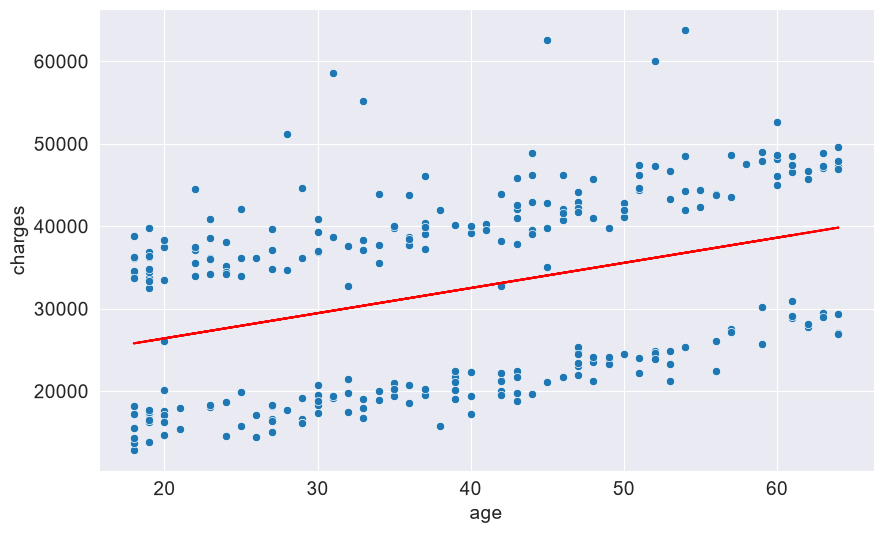

In [73]:
sns.scatterplot(smokers_df, x='age', y='charges')
predictions = estimate_charges(smokers_df['age'], age_smoker_model.coef_, age_smoker_model.intercept_)
plt.plot(smokers_df['age'], predictions, 'r')
plt.show()

### Estimate charges using age and bmi for non-smokers

In [74]:
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']
age_bmi_model = LinearRegression().fit(inputs, targets)
predictions = age_bmi_model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss: ', loss)

Loss:  4662.3128354612945


In [75]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.08403654312833271)

The correlation of non-smokers bmi with charges does not seem to exist or is very weak.  

Hence the loss from the model remains 4662.

In [76]:
fig = px.scatter(non_smoker_df, x='bmi', y='charges', title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

In [77]:
age_bmi_model.coef_, age_bmi_model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

### Estimate the charges based on No. of children, age and bmi for non-smokers

In [78]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542205)

The relationship between children and charges is weak and positive.

In [79]:
fig = px.strip(non_smoker_df, x='children', y='charges', title='Children vs. Charges')
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

In [80]:
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']
age_bmi_child_model = LinearRegression().fit(inputs, targets)
predictions = age_bmi_child_model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss: ', loss)

Loss:  4608.470405038246


The weak positive correlation leads to a decrease in error from 4662 to 4608

### Estimate medical charges for smokers based on age, bmi and children

In [81]:
smokers_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.059674,0.081183,0.368224
bmi,0.059674,1.000000,-0.012619,0.806481
children,0.081183,-0.012619,1.000000,0.035945
charges,0.368224,0.806481,0.035945,1.000000


In [82]:
inputs, target = smokers_df[['age', 'bmi', 'children']], smokers_df['charges']
age_bmi_child_s_model = LinearRegression().fit(inputs, target)
predictions = age_bmi_child_s_model.predict(inputs)

loss = rmse(target, predictions)
loss

np.float64(5718.202480524154)

The model on non-smokers, loss of 4608, was able to perform better compared to the one on smokers, loss of 5718.  

Maybe this is due to the small number of data available on smokers(<300) compared to non-smokers(>1000)

Text(0, 0.5, 'Predicted charges')

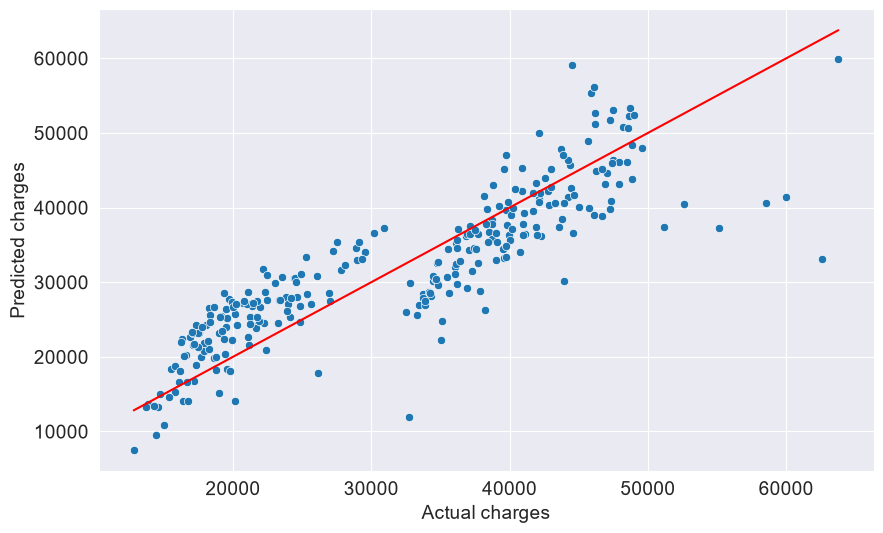

In [83]:
# Visualize the targets and predictions
sns.scatterplot(x=target, y=predictions)
plt.plot([target.min(), target.max()], [target.min(), target.max()], 'r')
plt.xlabel('Actual charges')
plt.ylabel('Predicted charges')

### Estimate medical charges for all customers

In [84]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [85]:
medical_df['charges']

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [86]:
inputs, target = medical_df[['age', 'bmi', 'children']], medical_df['charges']

age_bmi_child_all_model = LinearRegression().fit(inputs, target)
predictions = age_bmi_child_all_model.predict(inputs)
predictions

array([ 6908.77753344,  9160.97706103, 12390.94691779, ...,
        9640.92917145,  6691.39141657, 17377.08299024], shape=(1338,))

In [87]:
loss = rmse(target, predictions)
loss

np.float64(11355.317901125973)

When using both smokers and non-smokers data the error rises greatly to 11355 from 4608 in non-smokers and 5718 for smokers.

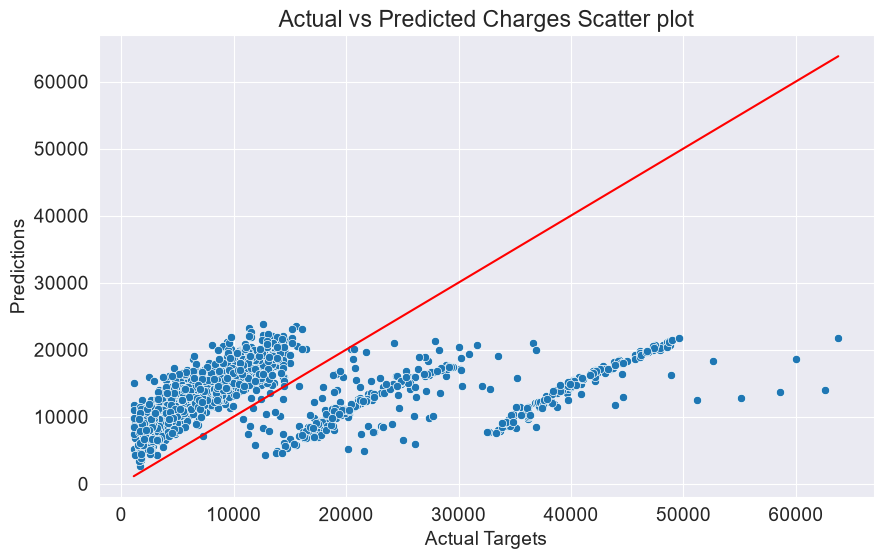

In [88]:
sns.scatterplot(x=target, y=predictions)
plt.plot([target.min(), target.max()], [target.min(), target.max()], 'r')
plt.xlabel('Actual Targets')
plt.ylabel('Predictions')
plt.title('Actual vs Predicted Charges Scatter plot')
plt.show()


### Encode categorical columns and train models

#### Transform smoker column

<Axes: xlabel='smoker', ylabel='charges'>

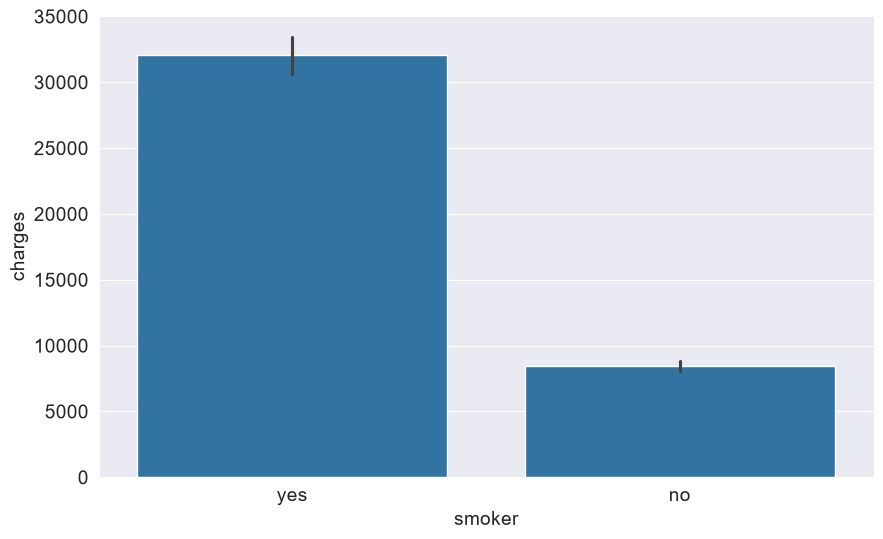

In [89]:
sns.barplot(medical_df, x='smoker', y='charges')

Two categories exist in the smoker column:  
1. smokers - denoted with 'yes'
2. non-smokers - denoted with 'no'

One-hot encoding the smoker column to use the values to train a model.  
(smoker)yes -> 1, (non-smoker)no -> 0 

In [90]:
smoker_codes = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df['smoker'].map(smoker_codes)

In [91]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [92]:
medical_df['charges'].corr(medical_df.smoker_code)

np.float64(0.7872514304984778)

The transformed smoker column(smoker_code) has a strong positive correlation with charges

#### Estimate charges with the smokers category added

In [ ]:
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

model_smoker = LinearRegression().fit(inputs, target)
predictions = model_smoker.predict(inputs)
loss = rmse(targets, predictions)
loss

np.float64(6056.439217188081)

The loss for the whole dataset decreases from 11355 to 6056 after using the new column, smoker_code, to train the model.

#### Transform sex column

<Axes: xlabel='sex', ylabel='charges'>

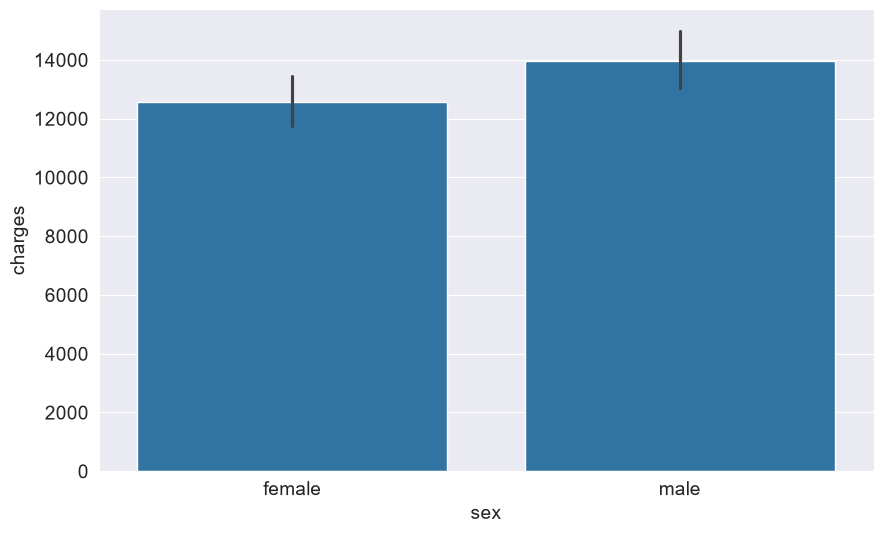

In [94]:
sns.barplot(medical_df, x='sex', y='charges')

We have two categories: male and female

female -> 0, male -> 1

In [95]:
sex_codes = {'female': 0, 'male': 1}

In [96]:
medical_df['sex_codes'] = medical_df['sex'].map(sex_codes)
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_codes
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [97]:
medical_df.charges.corr(medical_df.sex_codes)

np.float64(0.05729206220202533)

No relationship exists between sex and charges 

#### Estimating the charges with the sex added

In [ ]:
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_codes']], medical_df['charges']

model_sex = LinearRegression().fit(inputs, target)
predictions = model_sex.predict(inputs)
loss = rmse(targets, predictions)
loss

np.float64(6056.100708754546)

The error still remain 6056 since sex does not have any relationship with the charges.

#### Transform region column using Scikit Learn OneHotEncoder

<Axes: xlabel='region', ylabel='charges'>

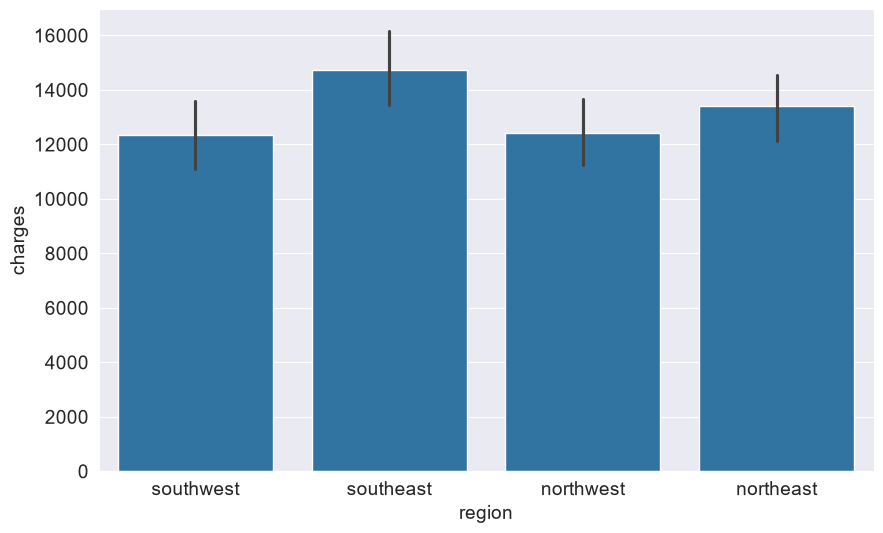

In [99]:
sns.barplot(medical_df, x='region', y='charges')

Four distinct regions exist: southwest, southeast, northwest and northeast

In [100]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
encoded = enc.fit_transform(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [101]:
one_hot = encoded.toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [102]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_codes,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [146]:
medical_df.corr(numeric_only=True).loc['charges', 'northeast':]

northeast    0.006349
northwest   -0.039905
southeast    0.073982
southwest   -0.043210
Name: charges, dtype: float64

The new columns have a weak correlation with charges

#### Estimate charges with the regions added

In [104]:
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_codes', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

model_regions = LinearRegression().fit(inputs, targets)
predictions = model_regions.predict(inputs)

loss = rmse(targets, predictions)
loss

np.float64(6041.6796511744515)

The error drops from 6056 to 6041.

#### Estimate charges for smokers and non smokers separately

In [ ]:
input_cols_wo_smoker = ['age', 'bmi', 'children', 'sex_codes', 'northeast', 'northwest', 'southeast', 'southwest']
smoker_df_enc = medical_df[medical_df['smoker'] == 'yes']
non_smoker_df_enc = medical_df[medical_df['smoker'] == 'no']

def get_predictions_targets(df):
  inputs, targets = df[input_cols_wo_smoker], df['charges']
  model_upd = LinearRegression().fit(inputs, targets)
  predictions = model_upd.predict(inputs)
  return targets, predictions, model_upd

smoker_targets, smoker_predictions, model_upd = get_predictions_targets(smoker_df_enc)
smoker_loss = rmse(smoker_targets, smoker_predictions)
non_smoker_targets, non_smoker_predictions, model_upd = get_predictions_targets(non_smoker_df_enc)
non_smoker_loss = rmse(non_smoker_targets, non_smoker_predictions)
print('Smokers Error: ', smoker_loss)
print('Non Smokers Error: ', non_smoker_loss)


Smokers Error:  5668.4678821121515
Non Smokers Error:  4573.074988795492


For smokers, error: 
- Before encoding categorical columns: 5718
- After encoding categorical columns: 5668

For non-smokers, error: 
- Before encoding categorical columns: 4608
- After encoding categorical columns: 4573

The error for both smokers and non-smokers was able to decline after encoding categorical columns and training the models

In [106]:
model_regions.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

### Feature Scaling

#### Standardization of numerical columns

In [107]:
from sklearn.preprocessing import StandardScaler

In [108]:
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(medical_df[numeric_cols])

StandardScaler()

In [109]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [110]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [111]:
medical_df[numeric_cols]

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0
...,...,...,...
1333,50,30.970,3
1334,18,31.920,0
1335,18,36.850,0
1336,21,25.800,0


Transform(standardize) the numerical columns to ensure values are on a similar scale

In [112]:
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]], shape=(1338, 3))

Get the categorical columns

In [113]:
cat_cols = ['smoker_code', 'sex_codes', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = medical_df[cat_cols].values
categorical_data

array([[1., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0., 0.]], shape=(1338, 6))

#### Combine the columns, train and evaluate the model with the updated inputs

In [114]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = medical_df.charges

model = LinearRegression().fit(inputs, target)
predictions = model.predict(inputs)

loss = rmse(targets, predictions)
loss

np.float64(6041.679651174452)

The error of the model remains 6041

In [115]:
weights_df = pd.DataFrame({
  'feature': np.append(numeric_cols + cat_cols, 1), 
  'weight': np.append(model.coef_, model.intercept_)
})

weights_df.sort_values('weight', ascending=False)

,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_codes,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


### Creating a test set

In [116]:
from sklearn.model_selection import train_test_split

10% of the data set will be used as the test set while 90% is for training 

In [117]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.1)

#### Train using training data and test using test data

In [118]:
model = LinearRegression().fit(inputs_train, targets_train)

predictions_test = model.predict(inputs_test)

loss = rmse(targets_test, predictions_test)
loss

np.float64(6702.6754954394955)

In [119]:
predictions_train = model.predict(inputs_train)
loss = rmse(targets_train, predictions_train)
loss

np.float64(5964.667552352115)

Test loss: 6702  
Training loss: 5964

### Estimating charges for a new customer

Pass 'age', 'bmi', 'children', 'smoker_code', 'sex_codes', 'northeast', 'northwest', 'southeast', 'southwest' to the model

In [120]:
new_customer = [[28, 30, 2, 1, 0, 0, 1, 0, 0.]]

Age, bmi and children are standardized

In [121]:
scaler.transform([[28, 30, 2]])

d:\Documents\Coding Prac\ML Projects\Predicting medical expenses using linear regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.79795355, -0.10882659,  0.75107928]])

In [122]:
model.predict([[-0.79795355, -0.10882659,  0.75107928, 1, 0, 0, 1, 0, 0.]])

array([29907.43108121])

"The customer should pay approximately 29907, plus or minus 6702, the test loss."